# E1/E2 analysis template — paired seeds, frozen weight selection, and multiplicity

**TL;DR.** This notebook encodes the analysis contract before GPU results exist. The authoritative
`aggregate_e1_sweep.py` command verifies the complete plan, run/audit provenance, and paired seed
cells before it builds a validation-only safety/utility frontier. The exact E2 selector separately
requires its complete 288-row validation factorial and freezes one positive weight in each of 18
domain/family/learned-arm strata. This notebook consumes only fail-closed aggregate interfaces; it
never reconstructs a result from an opportunistic subset of run directories and keeps final-test
labels out of selection. Persisted numerical examples are explicitly synthetic code regressions,
not method evidence.

Once either 48-task domain component is complete, run the aggregator documented in the E1 handoff and
then rerun this notebook. Incomplete aggregates remain visible as a ledger but cannot become a real
result panel.

## Assumptions and analysis contract

- Pair by the same training seed within task/model/history/dimension; never pool video frames as
  independent replicates.
- Minimize both validation world-model utility loss and the prospectively frozen validation safety
  defect. Report reconstruction and maximum-predeclared-horizon rollout pixel MSE separately; the
  family-dependent composite is not a global AE-versus-beta-VAE matching scale.
- Use the radius and safety budget frozen in `configs/e1_world_models/decisive_cart_grid.toml`.
- Three seeds are exploratory. The confirmatory contract uses exactly eight paired seeds, equal
  AE/beta-VAE averaging within each seed/domain, and 100,000 fixed-seed paired bootstrap replicates.
- The primary family is exactly 36 one-sided nonstudentized percentile UCBs at
  `1 - 0.05 / 36`, with Bonferroni simultaneity and fail-closed completeness.
- Holm correction is optional and secondary for the 12 safety contrasts only, and only when paired
  method labels are exchangeable under a predeclared sharp null.

In [1]:
from dataclasses import asdict, replace
from itertools import product
from pathlib import Path
import hashlib
import json
import sys
import tomllib

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif (ROOT / "LatentSafety" / "src").exists():
    ROOT = ROOT / "LatentSafety"
if not (ROOT / "src" / "latent_safety").exists():
    raise RuntimeError(f"Could not locate repository root from {Path.cwd()}")
sys.path.insert(0, str(ROOT / "src"))

from latent_safety.analysis import (
    BLOCK_INDEPENDENCE_CAVEAT,
    FROZEN_CONFIRMATORY_SPEC,
    VALIDATION_SELECTION_CAVEAT,
    ConfirmatoryObservation,
    HypothesisPValue,
    PairedBlock,
    PreconfirmationObservation,
    ValidationScore,
    exact_paired_sign_flip_test,
    holm_adjust,
    run_confirmatory_inference,
    run_preconfirmation_selection,
    select_under_safety_budget,
    validation_pareto_frontier,
)

GRID_PATH = ROOT / "configs" / "e1_world_models" / "decisive_cart_grid.toml"
with GRID_PATH.open("rb") as stream:
    grid_config = tomllib.load(stream)
analysis_config = grid_config["analysis"]
CONFIRMATORY_PATH = ROOT / "configs" / "e2_frontier" / "confirmatory_core.toml"
with CONFIRMATORY_PATH.open("rb") as stream:
    confirmatory_config = tomllib.load(stream)["inference"]

FROZEN_CONFIRMATORY_SPEC.validate()
assert confirmatory_config["bootstrap_resamples"] == FROZEN_CONFIRMATORY_SPEC.bootstrap_resamples
assert confirmatory_config["bootstrap_seed"] == FROZEN_CONFIRMATORY_SPEC.bootstrap_seed
assert confirmatory_config["elementary_bound_count"] == 36
assert np.isclose(
    confirmatory_config["primary_ucb_quantile"],
    FROZEN_CONFIRMATORY_SPEC.ucb_probability,
    atol=1e-15,
    rtol=0.0,
)
display({
    "block_caveat": BLOCK_INDEPENDENCE_CAVEAT,
    "selection_caveat": VALIDATION_SELECTION_CAVEAT,
    "exploratory_pilot_analysis_config": analysis_config,
    "frozen_confirmatory_spec": FROZEN_CONFIRMATORY_SPEC.to_dict(),
})

{'block_caveat': 'Each PairedBlock must represent one independent seed or one pre-aggregated, predeclared environment/trajectory block. Never enter correlated frames as separate blocks.',
 'selection_caveat': 'Frontier construction and budget selection may use validation metrics only. Final-test safety labels must not select configurations, checkpoints, budgets, or stopping times.',
 'exploratory_pilot_analysis_config': {'relative_radii': [0.0,
   0.01,
   0.02,
   0.05,
   0.1],
  'primary_relative_radius': 0.05,
  'max_validation_static_defect': 0.1,
  'bootstrap_resamples': 10000,
  'bootstrap_seed': 20260821,
  'selection_split': 'validation'},
 'frozen_confirmatory_spec': {'domains': ['controlled_cart_video',
   'controlled_pendulum_video',
   'controlled_dubins_navigation_pixels'],
  'model_families': ['ae', 'beta_vae'],
  'proposed_arm': 'nonprivileged_predicted_action_profile',
  'comparators': ['none',
   'h_prediction',
   'fcsrl_feasibility_loss_adaptation',
   'append_true_

## 1. Fail-closed aggregate audit

In [2]:
aggregate_paths = {
    "cart": ROOT / "runs" / "analysis" / "e1_pilot_validation.json",
    "pendulum": ROOT / "runs" / "analysis" / "e1_pendulum_pilot_validation.json",
}
aggregate_reports = {}
aggregate_status = {}
for domain, path in aggregate_paths.items():
    if not path.is_file():
        aggregate_status[domain] = {
            "artifact": path.relative_to(ROOT).as_posix(),
            "status": "missing",
            "analysis_ready": False,
        }
        continue
    report = json.loads(path.read_text(encoding="utf-8"))
    if report.get("schema_version") != 1:
        raise RuntimeError(f"Unsupported aggregate schema for {domain}: {path}")
    if report.get("selection_uses_test_data") is not False:
        raise RuntimeError(f"Aggregate does not preserve validation-only selection: {path}")
    completeness = report.get("completeness", {})
    aggregate_status[domain] = {
        "artifact": path.relative_to(ROOT).as_posix(),
        "status": report.get("status"),
        "analysis_ready": bool(report.get("analysis_ready")),
        "planned_tasks": completeness.get("planned_task_count"),
        "successful_tasks": completeness.get("successful_task_count"),
        "missing_tasks": completeness.get("missing_task_count"),
        "failed_tasks": completeness.get("failed_task_count"),
        "test_unblinded": report.get("test_unblinded"),
    }
    if report.get("status") == "complete" and report.get("analysis_ready") is True:
        aggregate_reports[domain] = report

display(aggregate_status)

{'cart': {'artifact': 'runs/analysis/e1_pilot_validation.json',
  'status': 'missing',
  'analysis_ready': False},
 'pendulum': {'artifact': 'runs/analysis/e1_pendulum_pilot_validation.json',
  'status': 'missing',
  'analysis_ready': False}}

## 2. Synthetic regression fixture for the frozen confirmatory inference

The complete 240-row fixture below is fabricated and labelled as such. It exercises the production
confirmatory API over `3 domains x 2 families x 5 arms/views x 8 seeds`. The API must produce all
36 primary bounds, use the frozen 100,000-resample one-sided Bonferroni UCB, and pass only because
every synthetic contrast was deliberately constructed to clear its gate. This is a code regression,
not empirical evidence.

In [3]:
synthetic_baseline = (0.42, 0.39, 0.46, 0.41, 0.44, 0.38, 0.45, 0.43)
synthetic_candidate = tuple(value - 0.12 for value in synthetic_baseline)
synthetic_observations = []
for domain, family, arm, seed in product(
    FROZEN_CONFIRMATORY_SPEC.domains,
    FROZEN_CONFIRMATORY_SPEC.model_families,
    (
        FROZEN_CONFIRMATORY_SPEC.proposed_arm,
        *FROZEN_CONFIRMATORY_SPEC.comparators,
    ),
    FROZEN_CONFIRMATORY_SPEC.paired_seeds,
):
    seed_index = FROZEN_CONFIRMATORY_SPEC.paired_seeds.index(seed)
    proposed = arm == FROZEN_CONFIRMATORY_SPEC.proposed_arm
    family_offset = 0.001 if family == "beta_vae" else 0.0
    synthetic_observations.append(
        ConfirmatoryObservation(
            domain=domain,
            model_family=family,
            arm=arm,
            seed=seed,
            safety=(
                synthetic_candidate[seed_index]
                if proposed
                else synthetic_baseline[seed_index]
            ),
            reconstruction=(1.02 if proposed else 1.0) + family_offset,
            rollout=(1.03 if proposed else 1.0) + family_offset,
            run_complete=True,
            coverage_complete=True,
        )
    )

synthetic_confirmatory = run_confirmatory_inference(synthetic_observations)
display({
    "status": "SYNTHETIC CONFIRMATORY API REGRESSION — NOT A RESULT",
    "input_observations": synthetic_confirmatory.input_observation_count,
    "elementary_bounds": len(synthetic_confirmatory.bounds),
    "safety_bounds": synthetic_confirmatory.safety_bound_count,
    "utility_bounds": synthetic_confirmatory.utility_bound_count,
    "ucb_probability": synthetic_confirmatory.spec.ucb_probability,
    "bootstrap_resamples": synthetic_confirmatory.spec.bootstrap_resamples,
    "bootstrap_seed": synthetic_confirmatory.spec.bootstrap_seed,
    "all_synthetic_bounds_passed": synthetic_confirmatory.all_elementary_bounds_passed,
})
assert synthetic_confirmatory.input_observation_count == 240
assert len(synthetic_confirmatory.bounds) == 36
assert synthetic_confirmatory.safety_bound_count == 12
assert synthetic_confirmatory.utility_bound_count == 24
assert synthetic_confirmatory.spec.bootstrap_resamples == 100_000
assert synthetic_confirmatory.spec.bootstrap_seed == 20_260_822
assert synthetic_confirmatory.all_elementary_bounds_passed

{'status': 'SYNTHETIC CONFIRMATORY API REGRESSION — NOT A RESULT',
 'input_observations': 240,
 'elementary_bounds': 36,
 'safety_bounds': 12,
 'utility_bounds': 24,
 'ucb_probability': 0.9986111111111111,
 'bootstrap_resamples': 100000,
 'bootstrap_seed': 20260822,
 'all_synthetic_bounds_passed': True}

## 3. Validation-only Pareto selection regression

In [4]:
synthetic_validation_scores = (
    ValidationScore("baseline", safety_defect=0.42, utility_loss=0.20),
    ValidationScore("h_prediction", safety_defect=0.31, utility_loss=0.22),
    ValidationScore("boundary", safety_defect=0.22, utility_loss=0.25),
    ValidationScore("action_profile", safety_defect=0.18, utility_loss=0.29),
    ValidationScore("dominated_control", safety_defect=0.45, utility_loss=0.30),
)
synthetic_frontier = validation_pareto_frontier(synthetic_validation_scores)
synthetic_selection = select_under_safety_budget(
    synthetic_frontier,
    max_safety_defect=0.25,
)
display({
    "status": "SYNTHETIC CODE REGRESSION — NOT A RESULT",
    "frontier": [asdict(point) for point in synthetic_frontier.points],
    "dominated": synthetic_frontier.dominated_config_ids,
    "selected_under_synthetic_budget_0.25": asdict(synthetic_selection),
})
assert "dominated_control" in synthetic_frontier.dominated_config_ids
assert synthetic_selection.config_id == "boundary"

{'status': 'SYNTHETIC CODE REGRESSION — NOT A RESULT',
 'frontier': [{'config_id': 'action_profile',
   'safety_defect': 0.18,
   'utility_loss': 0.29},
  {'config_id': 'boundary', 'safety_defect': 0.22, 'utility_loss': 0.25},
  {'config_id': 'h_prediction', 'safety_defect': 0.31, 'utility_loss': 0.22},
  {'config_id': 'baseline', 'safety_defect': 0.42, 'utility_loss': 0.2}],
 'dominated': ('dominated_control',),
 'selected_under_synthetic_budget_0.25': {'config_id': 'boundary',
  'safety_defect': 0.22,
  'utility_loss': 0.25}}

## 4. Exact 288-row validation-only weight-freeze regression

In [5]:
preconfirmation_rows = []
for domain, family, seed in product(
    FROZEN_CONFIRMATORY_SPEC.domains,
    FROZEN_CONFIRMATORY_SPEC.model_families,
    (0, 1, 2),
):
    preconfirmation_rows.append(
        PreconfirmationObservation(
            domain=domain,
            model_family=family,
            arm="none",
            seed=seed,
            weight=None,
            safety=0.50,
            reconstruction=1.00,
            rollout=2.00,
            eligible_center_coverage=0.90,
            neighborhood_mass=1.00,
            empty_trajectory_count=0,
            run_complete=True,
            coverage_complete=True,
        )
    )

learned_arms = (
    "h_prediction",
    "nonprivileged_predicted_action_profile",
    "fcsrl_feasibility_loss_adaptation",
)
positive_weights = (0.001, 0.01, 0.1, 1.0, 10.0)
safety_by_weight = {0.001: 0.45, 0.01: 0.40, 0.1: 0.30, 1.0: 0.32, 10.0: 0.38}
for domain, family, arm, seed, weight in product(
    FROZEN_CONFIRMATORY_SPEC.domains,
    FROZEN_CONFIRMATORY_SPEC.model_families,
    learned_arms,
    (0, 1, 2),
    positive_weights,
):
    is_profile = arm == "nonprivileged_predicted_action_profile"
    preconfirmation_rows.append(
        PreconfirmationObservation(
            domain=domain,
            model_family=family,
            arm=arm,
            seed=seed,
            weight=weight,
            safety=safety_by_weight[weight],
            reconstruction=1.02,
            rollout=2.04,
            eligible_center_coverage=0.88,
            neighborhood_mass=1.02,
            empty_trajectory_count=0,
            run_complete=True,
            coverage_complete=True,
            profile_normalized_p95_error=0.08 if is_profile else None,
            profile_teacher_count=5 if is_profile else None,
            profile_teacher_failure_count=0 if is_profile else None,
            profile_label_manifest_sha256=(
                hashlib.sha256(f"{domain}|{family}|{seed}".encode("utf-8")).hexdigest()
                if is_profile
                else None
            ),
        )
    )

synthetic_freeze = run_preconfirmation_selection(preconfirmation_rows)
assert synthetic_freeze.input_observation_count == 288
assert synthetic_freeze.required_selection_count == 18
assert synthetic_freeze.passed_selection_count == 18
assert synthetic_freeze.ready_for_confirmation
assert all(selection.selected_weight == 0.1 for selection in synthetic_freeze.selections)

failed_profile_rows = [
    replace(row, profile_normalized_p95_error=0.100001)
    if row.domain == FROZEN_CONFIRMATORY_SPEC.domains[0]
    and row.model_family == "ae"
    and row.arm == "nonprivileged_predicted_action_profile"
    else row
    for row in preconfirmation_rows
]
failed_freeze = run_preconfirmation_selection(failed_profile_rows)
assert not failed_freeze.ready_for_confirmation
assert failed_freeze.passed_selection_count == 17
display({
    "status": "SYNTHETIC PRECONFIRMATION FREEZE REGRESSION — NOT A RESULT",
    "input_observations": synthetic_freeze.input_observation_count,
    "required_strata": synthetic_freeze.required_selection_count,
    "selected_weights": sorted({
        selection.selected_weight for selection in synthetic_freeze.selections
    }),
    "all_constructed_strata_passed": synthetic_freeze.ready_for_confirmation,
    "profile_error_above_0.10_fails_closed": not failed_freeze.ready_for_confirmation,
    "passed_strata_after_planted_failure": failed_freeze.passed_selection_count,
})

{'status': 'SYNTHETIC PRECONFIRMATION FREEZE REGRESSION — NOT A RESULT',
 'input_observations': 288,
 'required_strata': 18,
 'selected_weights': [0.1],
 'all_constructed_strata_passed': True,
 'profile_error_above_0.10_fails_closed': True,
 'passed_strata_after_planted_failure': 17}

## 5. Optional secondary sign-flip/Holm regression for 12 safety contrasts

In [6]:
synthetic_secondary_tests = []
for bound in synthetic_confirmatory.bounds:
    if bound.endpoint != "safety":
        continue
    paired_blocks = tuple(
        PairedBlock(
            f"{bound.hypothesis_id}/seed-{seed.seed}",
            baseline=0.0,
            candidate=float(seed.equal_family_mean),
        )
        for seed in bound.seed_differences
    )
    synthetic_secondary_tests.append(
        exact_paired_sign_flip_test(
            paired_blocks,
            alternative="candidate_less",
            exchangeability_justification=(
                "synthetic paired method labels are exchangeable under the constructed sharp null"
            ),
        )
    )

synthetic_holm = holm_adjust(
    tuple(
        HypothesisPValue(bound.hypothesis_id, test.p_value)
        for bound, test in zip(
            (bound for bound in synthetic_confirmatory.bounds if bound.endpoint == "safety"),
            synthetic_secondary_tests,
            strict=True,
        )
    ),
    alpha=0.05,
)
display({
    "status": "OPTIONAL SYNTHETIC SECONDARY REGRESSION — NOT A PRIMARY RESULT",
    "scope": "12 safety contrasts only",
    "exchangeability_required": True,
    "raw_p_values": [test.p_value for test in synthetic_secondary_tests],
    "holm_rejections": [item.rejected for item in synthetic_holm],
})
assert len(synthetic_secondary_tests) == len(synthetic_holm) == 12
assert all(item.rejected for item in synthetic_holm)

{'status': 'OPTIONAL SYNTHETIC SECONDARY REGRESSION — NOT A PRIMARY RESULT',
 'scope': '12 safety contrasts only',
 'exchangeability_required': True,
 'raw_p_values': [0.00390625,
  0.00390625,
  0.00390625,
  0.00390625,
  0.00390625,
  0.00390625,
  0.00390625,
  0.00390625,
  0.00390625,
  0.00390625,
  0.00390625,
  0.00390625],
 'holm_rejections': [True,
  True,
  True,
  True,
  True,
  True,
  True,
  True,
  True,
  True,
  True,
  True]}

## 6. Visual regression checks

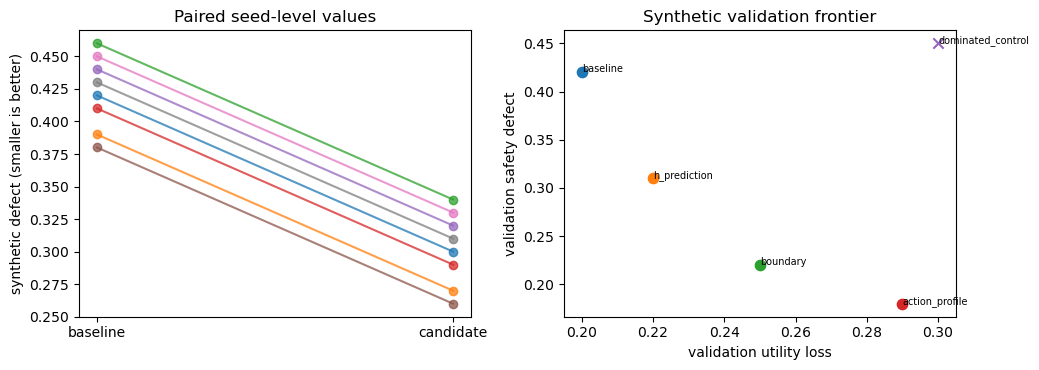

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
seed_indices = np.arange(len(synthetic_baseline))
for seed, baseline, candidate in zip(
    seed_indices, synthetic_baseline, synthetic_candidate, strict=True
):
    axes[0].plot([0, 1], [baseline, candidate], marker="o", alpha=0.75)
axes[0].set_xticks([0, 1], ["baseline", "candidate"])
axes[0].set_ylabel("synthetic defect (smaller is better)")
axes[0].set_title("Paired seed-level values")

for point in synthetic_validation_scores:
    on_frontier = point in synthetic_frontier.points
    axes[1].scatter(
        point.utility_loss,
        point.safety_defect,
        marker="o" if on_frontier else "x",
        s=55,
    )
    axes[1].annotate(point.config_id, (point.utility_loss, point.safety_defect), fontsize=7)
axes[1].set(xlabel="validation utility loss", ylabel="validation safety defect")
axes[1].set_title("Synthetic validation frontier")
fig.tight_layout()
plt.show()

## 7. Real pilot aggregate display (only complete, provenance-checked artifacts)

Frontier construction and paired inference happen in the fail-closed aggregator, which validates
the declared plan hash, factorial coverage, checkpoint provenance, audit radii, and complete seed
cells. This cell displays only reports whose status is `complete` and `analysis_ready`; a partial or
rejected report cannot enter. The final test table belongs in a separate, locked unblinding step
after the rule and included seeds are frozen.

In [8]:
if aggregate_reports:
    for domain, report in sorted(aggregate_reports.items()):
        frontier = report["validation_frontier"]
        utility_component_rows = [
            {
                "config_id": row["config_id"],
                "model_family": row["model_family"],
                "history_mode": row["history_mode"],
                "safety_arm": row["safety_arm"],
                "median_selection_composite": row["validation_median"]["utility_loss"],
                "median_reconstruction_mse": row["validation_median"]["reconstruction_mse"],
                "median_rollout_pixel_mse": row["validation_median"][
                    "rollout_pixel_mse_at_max_horizon"
                ],
                "rollout_horizon": row["rollout_summary_horizon"],
            }
            for row in report["model_rows"]
        ]
        display({
            "status": "REAL COMPLETE VALIDATION-ONLY PILOT AGGREGATE",
            "domain": domain,
            "source_plan_sha256": report["source_plan"]["plan_sha256"],
            "successful_tasks": report["completeness"]["successful_task_count"],
            "complete_seed_model_cells": len(report["model_rows"]),
            "frontier": frontier["points"],
            "predeclared_selection_status": frontier["budget_selection_status"],
            "predeclared_selection": frontier["selected"],
            "utility_component_rows": utility_component_rows,
            "paired_comparison_count": len(report["paired_seed_comparisons"]),
            "test_access": report["analysis_contract"]["test_access"],
        })
else:
    display(Markdown(
        "**No complete, analysis-ready GPU pilot aggregates found.** This is the expected "
        "repository state before the sweeps; only the explicitly synthetic regression outputs "
        "above are active. Run `scripts/aggregate_e1_sweep.py` after every planned task has "
        "finished."
    ))

**No complete, analysis-ready GPU pilot aggregates found.** This is the expected repository state before the sweeps; only the explicitly synthetic regression outputs above are active. Run `scripts/aggregate_e1_sweep.py` after every planned task has finished.

## Takeaways and unblinding gate

The inferential machinery is executable before results arrive: the frozen production API consumes
all 240 required observation rows and returns exactly 36 fixed-seed, one-sided Bonferroni UCBs.
Holm appears only as an optional secondary regression over the 12 safety contrasts. Generic pilot
Pareto selection and the exact 288-row E2 weight freeze remain validation-only and separate from
final-test inference; the notebook refuses to invent a real aggregate when run/audit artifacts are
missing.

Before any confirmatory test unblinding, freeze: included configuration IDs and failed runs; the
primary radius; safety budget; effect direction; paired-seed resampling unit; the complete 36-bound
family; and exact producing commit/environment. The current trainer's three-seed pilot evaluates
test for engineering convenience, so it is exploratory. A final study should use a deferred-test
execution path or an independent custodian to preserve a genuine blind.